# Does starting a 1P subscription increase 3P spend?

**The question.** Users who start a first-party (1P) subscription go on to spend more on
third-party (3P) apps and content, which is commission-generating revenue. How much of
that increase did the subscription *cause*, and how much would have happened anyway?

**Why it's hard.** Nobody was randomized. Users chose to subscribe, and the users who
did were more engaged and already spent about four times as much.

**About this notebook.** This is a simulated reconstruction of an analysis I did on
proprietary data. The data can't be shared, so `src/simulate.py` generates a dataset
with the same structure. **This notebook never sees the true effect**: it loads only the
columns an analyst would have, and chooses between methods using diagnostics, as you
must with real data. The companion notebook, `02_validation.ipynb`, uses the ground
truth to check this reasoning and to show when each method wins.

**Estimand.** The ATT: the average change in 28-day 3P spend caused by the
subscription, among users who started it.

| Section | Method | Package |
|---|---|---|
| 2 | Difference-in-differences | `statsmodels` |
| 3 | Inverse propensity score weighting (IPSW) | `scikit-learn` + `statsmodels` |
| 4 | Doubly robust DiD with ML nuisance models | `doubleml` (`DoubleMLDID`) |
| 5 | Which estimate to report, and why DoubleML even though parallel trends holds | |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from src.simulate import load_observed
from src import estimators as E
from src import diagnostics as D
from src.plotting import set_style, forest, TREATED, CONTROL, ALT, INK_2

set_style()
pd.set_option("display.float_format", "{:,.3f}".format)

SEED = 0

## 1. The data

One row per user. The subscription window starts on day 0. Everything prefixed `l28d_`
is measured over the 28 days before the window, so the treatment can't affect it.

| Column | Meaning |
|---|---|
| `started_1p_sub` | **Treatment**: started the 1P subscription during the window (binary) |
| `3p_spend_pre2` | 3P spend, days −56 to −29 |
| `3p_spend_pre` | 3P spend, days −28 to −1 |
| `3p_spend_post` | 3P spend, days 0 to 27 |
| `3p_spend_delta` | **Outcome**: post − pre. This is the change in spend, *not* the effect: non-subscribers' spend changes too |
| `l28d_app_sessions` | App-store sessions in the pre period (engagement) |
| `l28d_3p_num_orders` | 3P orders in the pre period |
| `l28d_3p_gamer` | Bought at least one game in the pre period |
| `l28d_new_buyer` | First-ever 3P purchase happened in the pre period |
| `l28d_3p_spend_categories` | Distinct 3P categories purchased in |
| `premium_device` | On a premium device |

In [2]:
obs = load_observed(seed=SEED)   # observed columns only; no ground truth in this notebook
obs.head()

,user_id,l28d_app_sessions,l28d_3p_num_orders,l28d_3p_gamer,l28d_new_buyer,l28d_3p_spend_categories,premium_device,3p_spend_pre2,3p_spend_pre,started_1p_sub,3p_spend_post,3p_spend_delta
0,0,8,0,0,0,0,0,0.000,0.000,0,0.000,0.000
1,1,7,0,0,0,0,0,0.000,0.000,0,6.059,6.059
2,2,50,7,0,0,4,1,140.251,221.805,0,460.498,238.693
3,3,10,0,0,0,0,0,0.000,0.000,0,0.000,0.000
4,4,11,0,0,0,0,0,0.000,0.000,0,0.000,0.000


**Is it realistic?** The simulator was tuned to plausible targets for an app-store
population (public orders of magnitude, not real platform figures):

In [3]:
payer = obs["3p_spend_pre"] > 0
top = np.sort(obs.loc[payer, "3p_spend_pre"].to_numpy())[::-1]

pd.DataFrame({
    "target": ["~25%", "~$10", "20-35%", "~5%"],
    "simulated": [
        f"{payer.mean():.1%}",
        f"${obs.loc[payer, '3p_spend_pre'].median():.2f}",
        f"{top[: len(top) // 100].sum() / top.sum():.0%}",
        f"{obs['started_1p_sub'].mean():.1%}",
    ],
}, index=[
    "Users with any 3P purchase in 28 days",
    "Median 28-day spend among payers",
    "Share of spend from top 1% of payers",
    "Subscription adoption",
])

,target,simulated
Users with any 3P purchase in 28 days,~25%,21.8%
Median 28-day spend among payers,~$10,$11.99
Share of spend from top 1% of payers,20-35%,22%
Subscription adoption,~5%,5.3%


In [4]:
cols = ["l28d_app_sessions", "premium_device", "l28d_3p_num_orders", "l28d_3p_gamer",
        "l28d_new_buyer", "l28d_3p_spend_categories",
        "3p_spend_pre2", "3p_spend_pre", "3p_spend_post", "3p_spend_delta"]
obs.groupby("started_1p_sub")[cols].mean().T.rename(columns={0: "did not subscribe", 1: "subscribed"})

started_1p_sub,did not subscribe,subscribed
l28d_app_sessions,11.143,18.262
premium_device,0.376,0.558
l28d_3p_num_orders,0.643,1.894
l28d_3p_gamer,0.095,0.211
l28d_new_buyer,0.004,0.008
l28d_3p_spend_categories,0.409,0.995
3p_spend_pre2,6.651,26.230
3p_spend_pre,6.788,26.613
3p_spend_post,6.776,29.037
3p_spend_delta,-0.012,2.424


Subscribers are more engaged, more often on premium devices, and spend about four times
as much. A naive post-period comparison would credit the subscription with all of that.
But notice that neither group's spend moved much from pre2 to pre: the groups differ in
*level*, not obviously in *trend*. That points to difference-in-differences.

## 2. Difference-in-differences

**Assumption:** without the subscription, subscribers' spend would have moved in parallel
with non-subscribers'. DiD tolerates level differences between groups, but not trend
differences.

**Diagnostic:** with two pre periods there is one pre-trend test: did the gap between the
groups change from pre2 to pre?

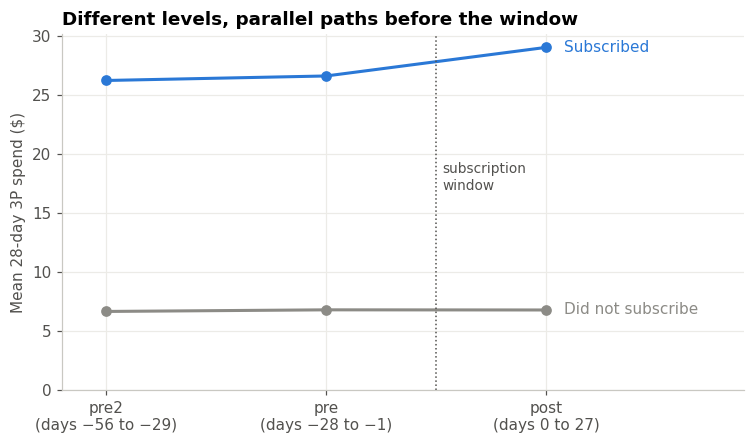

In [5]:
means = obs.groupby("started_1p_sub")[["3p_spend_pre2", "3p_spend_pre", "3p_spend_post"]].mean()
x = np.arange(3)

fig, ax = plt.subplots()
for g, color, label in [(1, TREATED, "Subscribed"), (0, CONTROL, "Did not subscribe")]:
    ax.plot(x, means.loc[g], color=color, marker="o", ms=6)
    ax.text(2.08, means.loc[g].iloc[-1], label, color=color, va="center")
ax.axvline(1.5, color=INK_2, lw=1, ls=":")
ax.text(1.53, 18, "subscription\nwindow", va="center", color=INK_2, fontsize=9)
ax.set_xticks(x, ["pre2\n(days −56 to −29)", "pre\n(days −28 to −1)", "post\n(days 0 to 27)"])
ax.set_xlim(-0.2, 2.9)
ax.set_ylim(0, None)
ax.set_ylabel("Mean 28-day 3P spend ($)")
ax.set_title("Different levels, parallel paths before the window")
plt.show()

In [6]:
es = E.event_study(obs)
es["ci_low"], es["ci_high"] = es.estimate - 1.96 * es.se, es.estimate + 1.96 * es.se
es

,estimate,se,ci_low,ci_high
period,,,,
pre2,-0.245,0.435,-1.098,0.607
pre,0.000,0.000,0.000,0.000
post,2.436,0.419,1.615,3.257


In [7]:
did = E.did(obs)
print(f"DiD estimate: ${did.att:.2f}  (95% CI ${did.ci[0]:.2f} to ${did.ci[1]:.2f})")

DiD estimate: $2.44  (95% CI $1.62 to $3.26)


**Verdict: credible.** The pre-trend coefficient is small and its confidence interval
contains zero.

**What a passing pre-trend test does not prove.**
1. *Power.* The pre-trend interval is roughly as wide as a third of the DiD estimate.
   A violation of that size couldn't be ruled out.
2. *The post period is untestable.* Parallel trends has to hold *after* launch, and the
   pre-period test only checks *before*. The realistic risk for spend data is a shock in
   the post period that scales with how much users spend, such as a holiday season or a
   big game launch. Subscribers spend about four times as much, so a proportional shock
   would hit them about four times harder in dollars, and DiD would credit it to the
   subscription.

The second risk can be checked indirectly. If a proportional post-period shock
happened, non-subscribers who spend more should show larger spend changes. Two checks:
change by engagement, and change by pre2 spend. Pre2 spend is used as the measure of how
much users spend, rather than pre-period spend, because pre-period spend is part of the
outcome (post − pre) and would mechanically regress to the mean.

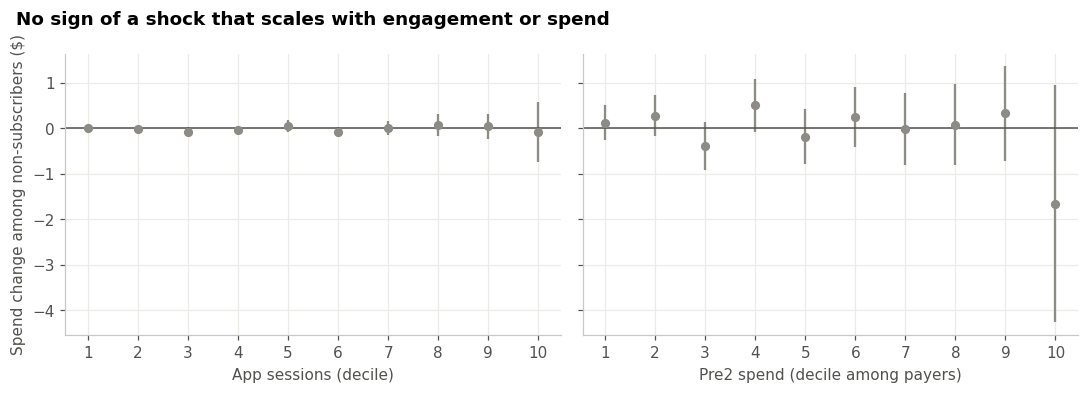

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, col, label in [(axes[0], "l28d_app_sessions", "App sessions (decile)"),
                       (axes[1], "3p_spend_pre2", "Pre2 spend (decile among payers)")]:
    src = obs if col == "l28d_app_sessions" else obs[obs["3p_spend_pre2"] > 0]
    prof = D.control_change_by(src, col)
    xx = np.arange(len(prof))
    ax.errorbar(xx, prof["mean"], yerr=1.96 * prof["sem"], fmt="o", color=CONTROL,
                ms=5, elinewidth=1.5)
    ax.axhline(0, color=INK_2, lw=1)
    ax.set_xticks(xx, [str(i + 1) for i in xx])
    ax.set_xlabel(label)
axes[0].set_ylabel("Spend change among non-subscribers ($)")
fig.suptitle("No sign of a shock that scales with engagement or spend", x=0.02, ha="left",
             fontweight="bold")
plt.tight_layout()
plt.show()

Flat within noise, even for the heaviest spenders. There's no evidence of a
spend-proportional shock in this window, so DiD's comparison looks safe. This check is
indirect, though: it shows untreated users weren't hit unevenly; it can't prove what
subscribers would have done.

## 3. Inverse propensity score weighting

Model each user's probability of subscribing from pre-period covariates, then reweight
non-subscribers by $p/(1-p)$ so they resemble subscribers. The outcome stays the change
in spend, so this is DiD with a reweighted control group.

**Assumption:** the propensity model is right. **Diagnostics** (none need the truth):
*overlap* (no propensities near 1), *effective sample size* (ESS), and *balance*
(standardized mean differences, SMD, below 0.1), including threshold and interaction
features the model never saw.

### 3a. Logistic regression on the raw columns

In [9]:
d = obs["started_1p_sub"].to_numpy()

p_logit_raw = E.fit_propensity(obs, "logit", log_skewed=False)
ipsw_logit_raw = E.ipsw(obs, p_logit_raw, "IPSW (logistic, raw)")
print(f"Estimate: ${ipsw_logit_raw.att:.2f}  (SE {ipsw_logit_raw.se:.2f})")
pd.Series(D.weight_summary(d, p_logit_raw)).to_frame("value")

Estimate: $76.23  (SE 42.94)


,value
max propensity,1.000
control ESS,5.098
control n,"946,776.000"
share of control weight on top 10 users,0.478


**Verdict: rejected.** Sessions and spend are heavily right-skewed, and in a linear logit
the extreme users get propensities of essentially 1. A handful of non-subscribers end
up carrying the whole counterfactual. The diagnostics alone disqualify it.

### 3b. Logistic regression on log sessions and log spend

In [10]:
p_logit = E.fit_propensity(obs, "logit", log_skewed=True)
ipsw_logit = E.ipsw(obs, p_logit, "IPSW (logistic)")
w_logit = E.att_weights(d, p_logit)
print(f"Estimate: ${ipsw_logit.att:.2f}  (95% CI ${ipsw_logit.ci[0]:.2f} to ${ipsw_logit.ci[1]:.2f})")
display(pd.Series(D.weight_summary(d, p_logit)).to_frame("value"))

bal = pd.DataFrame({"unweighted": D.smd(obs), "logistic IPSW": D.smd(obs, w_logit)})
bal.loc[D.DERIVED]

Estimate: $3.25  (95% CI $2.23 to $4.27)


,value
max propensity,0.834
control ESS,"478,635.361"
control n,"946,776.000"
share of control weight on top 10 users,0.001


,unweighted,logistic IPSW
heavy user (25+ sessions),0.657,0.293
heavy user & premium device,0.580,0.327
3+ categories,0.367,0.022


### 3c. Gradient-boosted propensity model

In [11]:
p_gbm = E.fit_propensity(obs, "gbm")
ipsw_gbm = E.ipsw(obs, p_gbm, "IPSW (boosted)")
w_gbm = E.att_weights(d, p_gbm)
bal["boosted IPSW"] = D.smd(obs, w_gbm)
print(f"Estimate: ${ipsw_gbm.att:.2f}  (95% CI ${ipsw_gbm.ci[0]:.2f} to ${ipsw_gbm.ci[1]:.2f})")
pd.Series(D.weight_summary(d, p_gbm)).to_frame("value")

Estimate: $2.66  (95% CI $1.67 to $3.65)


,value
max propensity,0.662
control ESS,"313,700.745"
control n,"946,776.000"
share of control weight on top 10 users,0.000


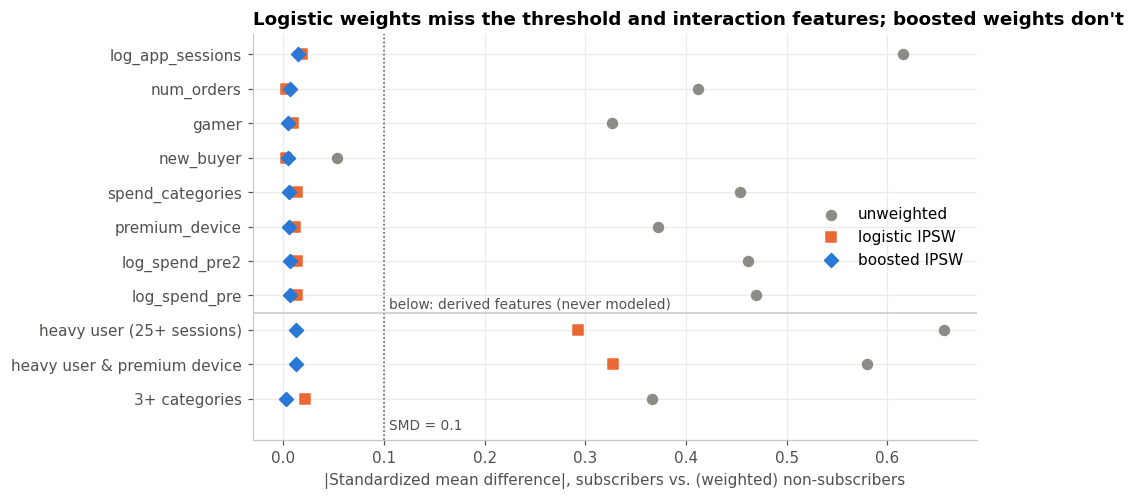

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
y = np.arange(len(bal))[::-1]
for col, color, marker in [("unweighted", CONTROL, "o"), ("logistic IPSW", ALT, "s"),
                           ("boosted IPSW", TREATED, "D")]:
    ax.scatter(bal[col], y, color=color, marker=marker, s=42, label=col, zorder=3)
ax.axvline(0.1, color=INK_2, lw=1, ls=":")
ax.text(0.105, -0.9, "SMD = 0.1", color=INK_2, fontsize=9)
ax.axhline(len(D.DERIVED) - 0.5, color="#c9c8c2", lw=1)
ax.text(0.105, len(D.DERIVED) - 0.35, "below: derived features (never modeled)", color=INK_2, fontsize=9)
ax.set_yticks(y, bal.index)
ax.set_ylim(-1.2, len(bal) - 0.4)
ax.set_xlabel("|Standardized mean difference|, subscribers vs. (weighted) non-subscribers")
ax.set_title("Logistic weights miss the threshold and interaction features; boosted weights don't")
ax.legend(loc="center right")
plt.show()

**Verdict.** Both pass overlap and ESS, and both balance every modeled covariate. The
difference is in the derived features: heavy users (25+ sessions), especially heavy
users on premium devices, stay clearly unbalanced under the logistic weights. Selection
runs through a threshold and an interaction that a main-effects logit can't represent,
and checking balance only on the modeled columns would have hidden it. So logistic
IPSW is **suspect**, and its estimate sits above the others. Boosted IPSW balances
everything and is **credible**.

IPSW's structural weakness remains even when it passes: it rests entirely on the
propensity model, with no outcome model to catch its errors.

## 4. DoubleML: doubly robust DiD

`doubleml.DoubleMLDID` implements the doubly robust DiD estimator of Sant'Anna & Zhao
(2020) with machine-learning nuisance models (Chernozhukov et al., 2018):

- $g_0(x) = E[\Delta Y \mid X=x, D=0]$: the spend change a user with these covariates would
  have without subscribing (gradient-boosted regression)
- $m(x) = P(D=1 \mid X=x)$: the propensity (gradient-boosted classifier)

Both are fit with 5-fold cross-fitting, so each user's predictions come from models
trained on other users. The estimate is consistent if either nuisance model is right.

**Assumption:** *conditional* parallel trends: subscribers and non-subscribers with the
same pre-period covariates would have had the same spend change. This is weaker than
DiD's unconditional version in one important way: it still holds if a post-period shock
hits users differently *according to their covariates*.

In [13]:
dml_est, dml_model = E.dml_did(obs, seed=SEED)
print(f"DoubleML DiD: ${dml_est.att:.2f}  (95% CI ${dml_est.ci[0]:.2f} to ${dml_est.ci[1]:.2f})")

DoubleML DiD: $2.61  (95% CI $1.64 to $3.57)


### Diagnostics

**Nuisance model quality** (out-of-fold predictions stored by DoubleML):

In [14]:
m_hat = dml_model.predictions["ml_m"][:, 0, 0]
g0_hat = dml_model.predictions["ml_g0"][:, 0, 0]
y = obs["3p_spend_delta"].to_numpy()
ctrl = d == 0

pd.Series({
    "propensity model: out-of-fold AUC": roc_auc_score(d, m_hat),
    "outcome model: out-of-fold R² (non-subscribers)":
        1 - np.mean((y[ctrl] - g0_hat[ctrl]) ** 2) / np.var(y[ctrl]),
    "propensities clipped at 0.01 / 0.99": int(((m_hat < 0.01) | (m_hat > 0.99)).sum()),
}).to_frame("value")

,value
propensity model: out-of-fold AUC,0.690
outcome model: out-of-fold R² (non-subscribers),0.196
propensities clipped at 0.01 / 0.99,0.000


The propensity model has real signal. The outcome model explains about a fifth of the
variation in spend change, mostly regression to the mean (users with an unusually high
pre-period tend to come back down). The rest is order-level noise, such as whether a
whale happened to make a few large purchases this month, which no covariate can
predict. That limits how much precision covariate adjustment can buy, which matters in
Section 5.

**Learner stability.** Refit with a shallower boosted model and with linear models:

In [15]:
shallow = dict(max_iter=200, learning_rate=0.05, max_depth=3)
lin_g, lin_m = E.linear_learners()
variants = [
    dml_est,
    E.dml_did(obs, ml_g=HistGradientBoostingRegressor(**shallow, random_state=SEED),
              ml_m=HistGradientBoostingClassifier(**shallow, random_state=SEED),
              seed=SEED, label="DoubleML DiD, shallow boosting")[0],
    E.dml_did(obs, ml_g=lin_g, ml_m=lin_m, seed=SEED, label="DoubleML DiD, linear models")[0],
]
pd.DataFrame([{"estimate": v.att, "se": v.se, "ci_low": v.ci[0], "ci_high": v.ci[1]}
              for v in variants], index=[v.method for v in variants])

,estimate,se,ci_low,ci_high
DoubleML DiD,2.606,0.491,1.644,3.568
"DoubleML DiD, shallow boosting",2.556,0.488,1.599,3.513
"DoubleML DiD, linear models",3.238,0.512,2.233,4.242


The two boosted versions agree. The linear version lands higher, next to logistic IPSW,
for the same reason: linear models can't represent the 25-session threshold. Double
robustness can't rescue an estimate when both nuisance models share the same blind spot.

### A deliberate decision: winsorize the outcome?

Whales dominate the variance. Capping spend at the 99.9th percentile of pre-period spend
before taking the change is a common fix:

In [16]:
obs["3p_spend_delta_capped"], cap = E.winsorize_outcome(obs)
dml_capped, _ = E.dml_did(obs, outcome="3p_spend_delta_capped", seed=SEED,
                          label="DoubleML DiD, capped spend")
pd.DataFrame([{"estimate": v.att, "se": v.se, "ci_low": v.ci[0], "ci_high": v.ci[1]}
              for v in [dml_est, dml_capped]],
             index=["raw spend", f"spend capped at ${cap:,.0f}"])

,estimate,se,ci_low,ci_high
raw spend,2.606,0.491,1.644,3.568
spend capped at $609,2.091,0.232,1.637,2.546


Capping shrinks the standard error, but it also changes the question: if the
subscription lifts spend proportionally, heavy spenders produce much of the dollar lift,
and capping removes real effect along with noise. I report the capped estimate
alongside the raw one, not instead of it. For a revenue decision, the raw ATT is the
relevant number.

### Sensitivity to unobserved confounding

DoubleML can quantify how strong an unmeasured confounder would have to be to overturn
the result (Chernozhukov et al., 2022). The *robustness value* is the share of residual
variation in both treatment and outcome that a confounder would need to explain to push
the estimate to zero.

In [17]:
dml_model.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0)
print(dml_model.sensitivity_summary)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                CI lower  theta lower   theta  theta upper  CI upper
started_1p_sub    -3.567       -2.755   2.606        7.968     8.825

------------------ Robustness Values ------------------
                 H_0  RV (%)  RVa (%)
started_1p_sub 0.000   1.470    1.020


## 5. Which estimate to report, and why DoubleML when parallel trends holds

The methods that passed their diagnostics agree:

In [18]:
candidates = [did, ipsw_logit_raw, ipsw_logit, ipsw_gbm, dml_est, dml_capped]
verdicts = {
    "DiD": ("Pre-trend test passes; no sign of spend-scaled shocks", "credible"),
    "IPSW (logistic, raw)": ("Propensities near 1; ESS collapses", "rejected"),
    "IPSW (logistic)": ("Threshold/interaction features unbalanced", "suspect"),
    "IPSW (boosted)": ("Overlap and balance pass, incl. derived features", "credible"),
    "DoubleML DiD": ("Nuisance models have signal; stable across boosted learners", "credible"),
    "DoubleML DiD, capped spend": ("Narrower estimand (extreme spend excluded)", "secondary"),
}
summary5 = pd.DataFrame([{
    "estimate": c.att, "ci_low": c.ci[0], "ci_high": c.ci[1],
    "CI half-width": 1.96 * c.se,
    "diagnostic": verdicts[c.method][0], "verdict": verdicts[c.method][1],
} for c in candidates], index=[c.method for c in candidates])
summary5

,estimate,ci_low,ci_high,CI half-width,diagnostic,verdict
DiD,2.436,1.615,3.257,0.821,Pre-trend test passes; no sign of spend-scaled...,credible
"IPSW (logistic, raw)",76.227,-7.941,160.396,84.168,Propensities near 1; ESS collapses,rejected
IPSW (logistic),3.253,2.234,4.272,1.019,Threshold/interaction features unbalanced,suspect
IPSW (boosted),2.659,1.670,3.648,0.989,"Overlap and balance pass, incl. derived features",credible
DoubleML DiD,2.606,1.644,3.568,0.962,Nuisance models have signal; stable across boo...,credible
"DoubleML DiD, capped spend",2.091,1.637,2.546,0.455,Narrower estimand (extreme spend excluded),secondary


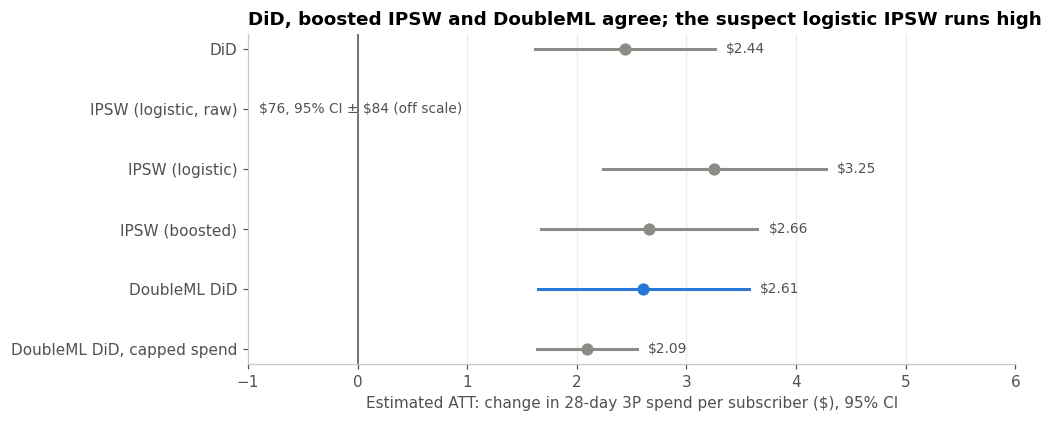

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.9))
forest(ax, candidates, "DoubleML DiD", xlim=(-1, 6))
ax.set_title("DiD, boosted IPSW and DoubleML agree; the suspect logistic IPSW runs high")
plt.show()

DiD passed its test, so why run DoubleML at all? The honest answer is not precision:
here DoubleML's interval is *wider* than DiD's (see the CI half-widths in the table).
What the outcome model gains is outweighed by the variance the propensity weights add.

The reasons are about which assumption fails *if* something is wrong:

| Threat | Can the data rule it out? | DiD | DoubleML |
|---|---|---|---|
| A post-period shock that scales with spend or engagement (holidays, a big launch) | Only indirectly (Section 2) | **Biased**: subscribers spend 4× more, so they absorb 4× the shock | Protected: compares users with the same covariates |
| Selection on spending traits the data only captures noisily | Partly (below) | Protected, as long as parallel trends holds | **Biased**: conditioning on noisy pre-period spend reintroduces regression to the mean |

Each method covers the other's blind spot. So **the agreement is the result**: the
estimate holds under either threat.

The second threat can be probed too. If subscription were driven by underlying spending
traits, pre-period spend would help predict who subscribes even after engagement and
device are known:

In [20]:
engagement_cols = ["l28d_app_sessions", "premium_device"]
auc = D.selection_auc(obs, {
    "engagement + device": engagement_cols,
    "all pre-period covariates": E.COVARIATES,
})
auc.to_frame("out-of-fold AUC for predicting subscription")

,out-of-fold AUC for predicting subscription
engagement + device,0.690
all pre-period covariates,0.690


Spend history adds essentially nothing once engagement and device are known.
Subscription looks driven by engagement, which is observed, so DoubleML's
regression-to-the-mean risk looks small here.

**What I report.** The DoubleML DiD estimate, raw spend, with DiD and boosted IPSW
alongside it. DoubleML is the headline because its failure mode (selection on noisily
observed traits) shows no sign in the data, while DiD's failure mode (a spend-scaled
post-period shock) can only be ruled out indirectly and is common in spend data. The
cost is a somewhat wider interval, which I'd rather accept than lean on an untestable
assumption. The capped estimate goes in a footnote as a more precise answer to a
narrower question.

**Caveat that goes with the number.** The sensitivity analysis shows a small robustness
value: a confounder explaining only a percent or two of the residual variation could
erase the effect. With an outcome this noisy relative to the effect, no observational
estimate here is robust to strong hidden confounding.

## 6. What I'd do differently, and next steps

**Randomize a holdout at launch.** Withholding the subscription offer from a small
random share of eligible users answers the question with no modeling assumptions and
gives the observational estimates something to be validated against. Given the
sensitivity result, this is the single most valuable change.

**Ask who benefits, not just how much.** This analysis estimates the average lift. The
follow-up is heterogeneity: does the lift concentrate among gamers or heavy spenders?
That's a CATE question, where a tool such as EconML's `CausalForestDML` fits, and it
would inform whom to target with the offer.

**Validation.** `02_validation.ipynb` reveals the true effect for this dataset and uses
repeated simulation to test the Section 5 argument: that DiD and DoubleML each fail
under a different threat.